# 2D Poisson Equation — Weak Formulation with `ProblemWeak`

Solve the **Poisson equation** on the unit square using the **Galerkin weak formulation**
with P1 Lagrange test functions and Dunavant cubature:

$$-\nabla^2 u = f \quad \text{in } \Omega = [0,1]^2$$

**Analytical solution (used for validation):**

$$u^*(x,y) = \sin(\pi x)\sin(\pi y), \qquad f(x,y) = 2\pi^2\sin(\pi x)\sin(\pi y)$$

**Boundary conditions:** $u = 0$ on all four sides (Dirichlet).

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "pinn_models"))

import pinns
pinns.use_backend("jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import jax
import jax.numpy as jnp

print("JAX backend:", jax.default_backend())
print("Available devices:", jax.devices())

pinns: Using jax backend
JAX backend: gpu
Available devices: [CudaDevice(id=0)]


## 1. Build the mesh

We triangulate the unit square $[0,1]^2$ using `pygmsh` and extract the four boundary edge groups.

In [2]:
import pygmsh

mesh_size = 0.05   # target element size — decrease for a finer mesh

with pygmsh.geo.Geometry() as geom:
    # ── Unit-square corners ──────────────────────────────────────────────
    p0 = geom.add_point([0.0, 0.0, 0.0], mesh_size=mesh_size)
    p1 = geom.add_point([1.0, 0.0, 0.0], mesh_size=mesh_size)
    p2 = geom.add_point([1.0, 1.0, 0.0], mesh_size=mesh_size)
    p3 = geom.add_point([0.0, 1.0, 0.0], mesh_size=mesh_size)

    # ── Boundary lines ───────────────────────────────────────────────────
    l_bottom = geom.add_line(p0, p1)   # y = 0
    l_right  = geom.add_line(p1, p2)   # x = 1
    l_top    = geom.add_line(p2, p3)   # y = 1
    l_left   = geom.add_line(p3, p0)   # x = 0

    loop    = geom.add_curve_loop([l_bottom, l_right, l_top, l_left])
    surface = geom.add_plane_surface(loop)

    # ── Physical groups (for named boundary extraction) ──────────────────
    geom.add_physical(l_bottom, "bottom")
    geom.add_physical(l_right,  "right")
    geom.add_physical(l_top,    "top")
    geom.add_physical(l_left,   "left")
    geom.add_physical(surface,  "interior")

    mesh = geom.generate_mesh(dim=2, verbose=False)

# ── Extract arrays ────────────────────────────────────────────────────────
verts = mesh.points[:, :2]           # (n_verts, 2) — drop z
faces = mesh.cells_dict["triangle"]  # (n_faces, 3)

print(f"Mesh: {len(verts)} vertices, {len(faces)} triangles")


def boundary_edges(mesh, name):
    """Return (n_edges, 2) vertex-index pairs for a named physical group."""
    if name in mesh.cell_sets_dict:
        for cell_type, block_indices in mesh.cell_sets_dict[name].items():
            if "line" in cell_type:
                cells = mesh.cells_dict.get(cell_type)
                if cells is not None:
                    return cells[block_indices]
    raise KeyError(f"Physical group '{name}' not found.")


edges_bottom = boundary_edges(mesh, "bottom")
edges_right  = boundary_edges(mesh, "right")
edges_top    = boundary_edges(mesh, "top")
edges_left   = boundary_edges(mesh, "left")

print(f"Boundary edges — bottom:{len(edges_bottom)} right:{len(edges_right)} "
      f"top:{len(edges_top)} left:{len(edges_left)}")

Mesh: 513 vertices, 944 triangles
Boundary edges — bottom:20 right:20 top:20 left:20


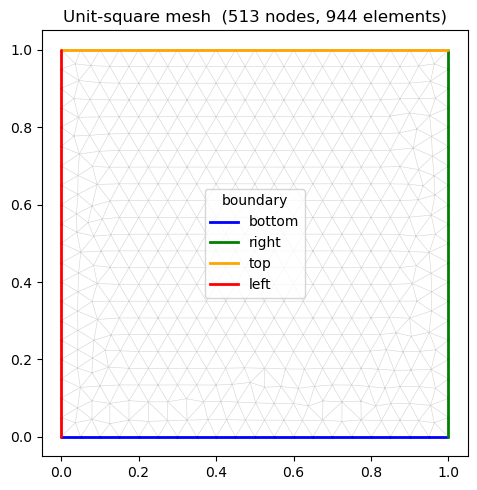

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
tri_plot = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_plot, color="lightgray", lw=0.4)

colors = {"bottom": "blue", "right": "green", "top": "orange", "left": "red"}
for bname, bedges in [("bottom", edges_bottom), ("right", edges_right),
                      ("top", edges_top),       ("left", edges_left)]:
    for v0, v1 in bedges:
        ax.plot(verts[[v0, v1], 0], verts[[v0, v1], 1],
                color=colors[bname], lw=2, solid_capstyle="round")
    ax.plot([], [], color=colors[bname], lw=2, label=bname)

ax.set_aspect("equal")
ax.legend(title="boundary")
ax.set_title(f"Unit-square mesh  ({len(verts)} nodes, {len(faces)} elements)")
plt.tight_layout()
plt.show()

## 2. Domain and boundary conditions

All four sides have homogeneous Dirichlet BCs ($u = 0$), consistent with the analytical solution $u^* = \sin(\pi x)\sin(\pi y)$.

In [4]:
domain = pinns.DomainMesh(mesh)   # purely spatial — no t_interval

# Homogeneous Dirichlet on all four sides
domain.add_dirichlet(select=edges_bottom, value=0.0, component=0, name="bottom")
domain.add_dirichlet(select=edges_right,  value=0.0, component=0, name="right")
domain.add_dirichlet(select=edges_top,    value=0.0, component=0, name="top")
domain.add_dirichlet(select=edges_left,   value=0.0, component=0, name="left")

for bc in domain.boundary_conditions:
    print(f"  {bc.name:10s}  {len(bc.node_positions):4d} nodes  type={bc.bc_type}")
print(domain)

  bottom        21 nodes  type=dirichlet
  right         21 nodes  type=dirichlet
  top           21 nodes  type=dirichlet
  left          21 nodes  type=dirichlet
DomainMesh(2D, n_nodes=513, n_conditions=4)


## 3. Define the ProblemWeak

`volume_fn` mirrors the **strong-form** `pde_fn(x, y, params, derivative=None)` exactly,
with two extra trailing arguments for the test functions:

```
volume_fn(x, y, params, phi, grad_phi, derivative=None) -> (n_pts,)
```

| arg | shape | meaning |
|-----|-------|---------|
| `x` | `(n, 2)` | quadrature point coordinates |
| `y` | `(n, n_out)` | network output — same layout as strong-form |
| `params` | dict | `{"fixed": ..., "infer": ..., "internal": ...}` — same as strong-form |
| `phi` | `(n,)` | test function $\varphi_j$ values at the quadrature points |
| `grad_phi` | `(n, 2)` | $\nabla\varphi_j$ in physical coords (from cubature precomputation) |
| `derivative` | callable | same API as strong-form: `derivative(y, x, comp, order)` |

In [5]:
def fn(x, y, params, derivative=None):
    # ∇u via the same derivative API as the strong form
    du_xx = derivative(y, x, 0, (0,0))           # (n,)
    du_yy = derivative(y, x, 0, (1,1))           # (n,)

    f = 2.0 * jnp.pi**2 * jnp.sin(jnp.pi * x[:, 0]) * jnp.sin(jnp.pi * x[:, 1])
    return du_xx + du_yy - f

problem = pinns.Problem(
    domain=domain,
    pde_fn=fn,
    input_names=["x", "y"],
    output_names=["u"],
    solution=lambda xy: np.sin(np.pi * xy[:, 0]) * np.sin(np.pi * xy[:, 1]),
)


## 4. Training

`Trainer` detects `ProblemWeak` automatically and replaces the strong-form collocation
residual with the FEM weak-form assembly. Boundary conditions are penalised the same
way as in a strong-form problem:

```python
trainer = pinns.Trainer(problem, network)
trainer.compile(optimizer="adam", learning_rate=..., epochs=...)
trainer.train()
```

Trained parameters are in `trainer.network.params` and the loss history in `trainer.history`.

Starting training for 100000 epochs (JIT-compiled)...


ValueError: z array must have same length as triangulation x and y arrays

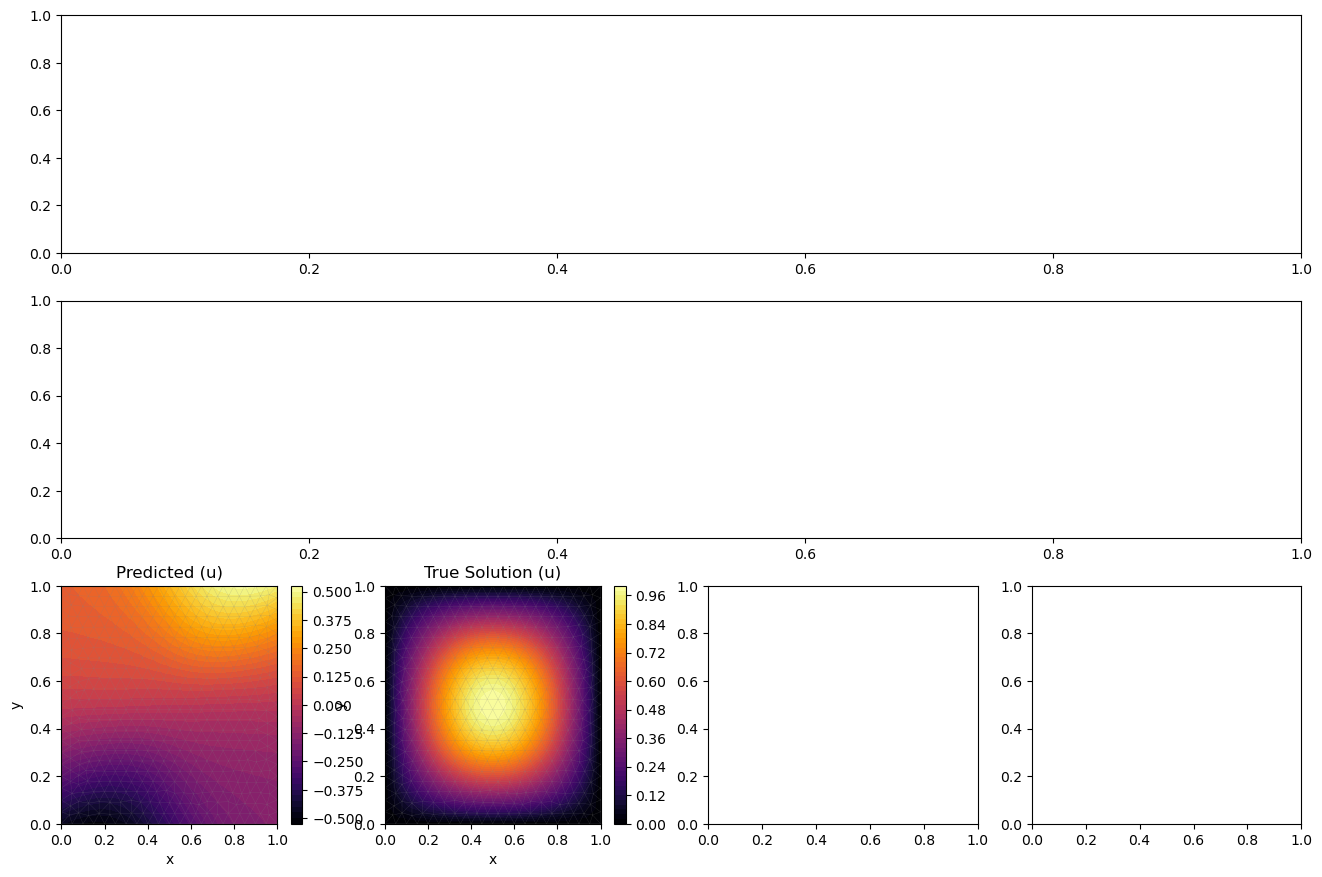

In [6]:
network = pinns.FNN([2, 64, 64, 64, 1], activation="tanh")

trainer = pinns.Trainer(problem, network)
trainer.compile(
    train_samples={"pde": 800, "bottom": 51, "right": 51, "top": 51, "left": 51},
    weights={"pde": 1.0, "bottom": 1.0, "right": 1.0, "top": 1.0, "left": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=100000,
    print_each=1000,
    show_plots=True,
)
trainer.train()